In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
gaia_path = '/global/cfs/cdirs/desi/users/rongpu/useful/gaia_edr3_g_14_pm_dr9.fits'
gaia = Table(fitsio.read(gaia_path))

gaia_decam_path1 = '/global/cfs/cdirs/desi/users/rongpu/useful/gaia_edr3_g_18_dr9.fits'
gaia_decam_path2 = '/global/cfs/cdirs/desi/users/rongpu/useful/gaia_edr3_g_18_dr9-predict_decam.fits'
gaia_decam1 = Table(fitsio.read(gaia_decam_path1, columns=['SOURCE_ID']))
gaia_decam2 = Table(fitsio.read(gaia_decam_path2))
gaia_decam = hstack([gaia_decam1, gaia_decam2])

mask = np.in1d(gaia_decam['SOURCE_ID'], gaia['SOURCE_ID'])
gaia_decam = gaia_decam[mask]

gaia = join(gaia, gaia_decam, keys='SOURCE_ID')

In [4]:
tycho2 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/Tycho-2-reference.fits'))
tycho2_dr9 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/Tycho-2-dr9.fits'))
mask = np.in1d(tycho2['idx'], tycho2_dr9['idx'])
mask &= np.isfinite(tycho2['zguess'])
tycho2 = tycho2[mask]

tycho2.rename_columns(['RAmdeg', 'DEmdeg'], ['RA', 'DEC'])

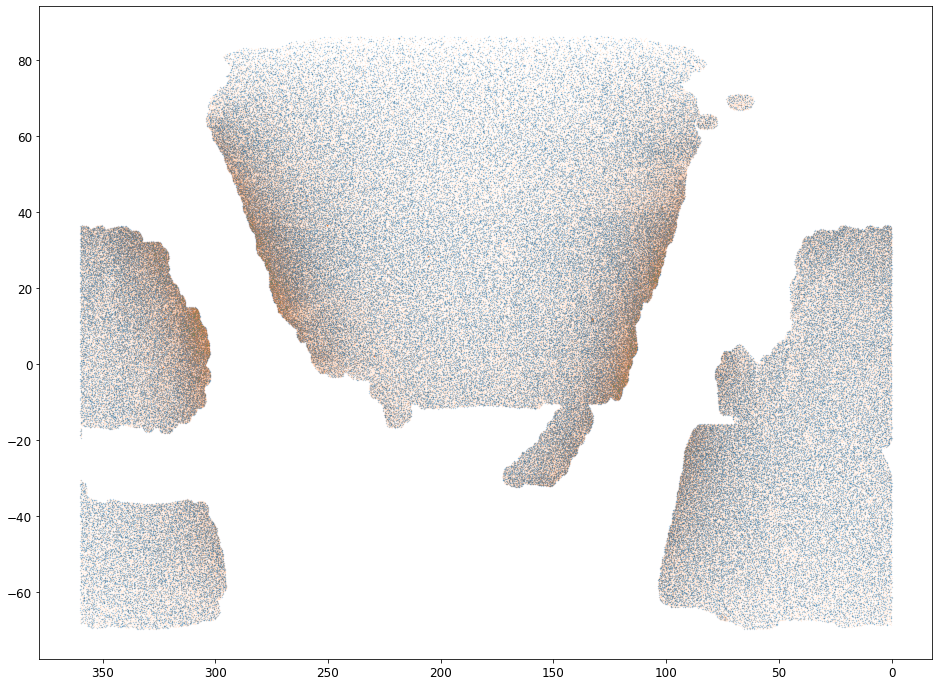

In [5]:
plt.figure(figsize=(16, 12))
plt.plot(tycho2['RA'][::5], tycho2['DEC'][::5], '.', ms=0.5, alpha=0.5)
plt.plot(gaia['RA'][::10], gaia['DEC'][::10], '.', ms=0.1, alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

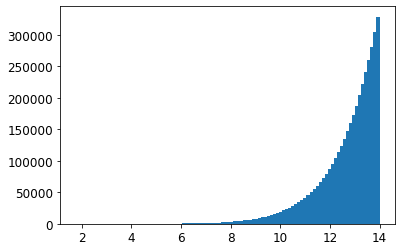

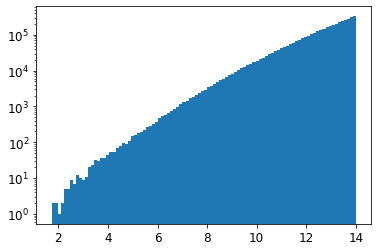

In [6]:
plt.hist(gaia['PHOT_G_MEAN_MAG'], 100)
plt.show()

plt.hist(gaia['PHOT_G_MEAN_MAG'], 100, log=True)
plt.show()

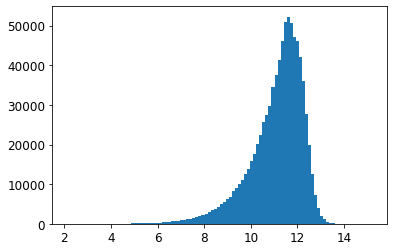

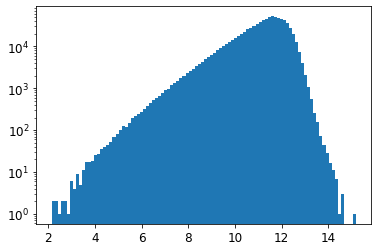

In [7]:
plt.hist(tycho2['VTmag'], 100)
plt.show()

plt.hist(tycho2['VTmag'], 100, log=True)
plt.show()

In [8]:
mask = gaia['PHOT_G_MEAN_MAG']<14
print(np.sum(mask)/len(mask))
gaia = gaia[mask]

1.0


In [9]:
mask = tycho2['VTmag']<10.
print(np.sum(mask)/len(mask))
tycho2 = tycho2[mask]

0.14917260911644034


In [10]:
gaia['RA2000'] = gaia['RA'] - 16 * gaia['PMRA'] * 1e-3/3600 / np.cos(np.radians(gaia['DEC']))
gaia['DEC2000'] = gaia['DEC'] - 16 * gaia['PMDEC'] * 1e-3/3600

Doubly matched objects = 0
Final matched objects = 124624


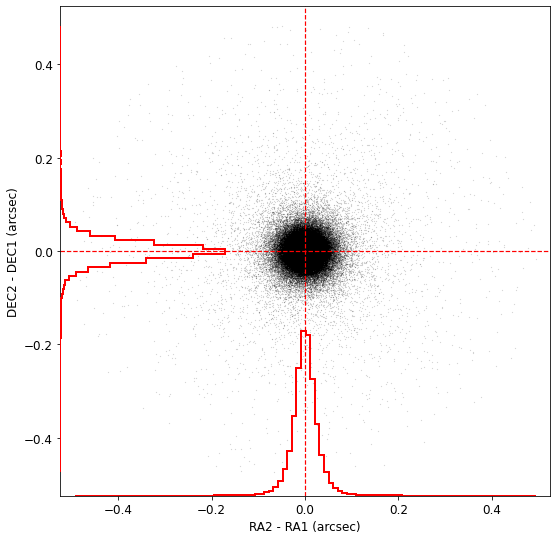

0.03092905036071566
0.9920792236843152


In [13]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
from match_coord import match_coord

idx1, idx2, d2d, d_ra, d_dec = match_coord(gaia['RA2000'], gaia['DEC2000'], tycho2['RA'], tycho2['DEC'], search_radius=0.5, plot_q=True)

print(len(idx1)/len(gaia))
print(len(idx1)/len(tycho2))

In [14]:
gaia = gaia[idx1]
tycho2 = tycho2[idx2]

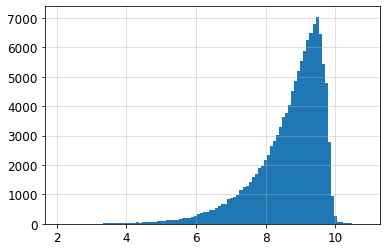

In [15]:
plt.hist(gaia['PHOT_G_MEAN_MAG'], 100)
plt.grid(alpha=0.5)

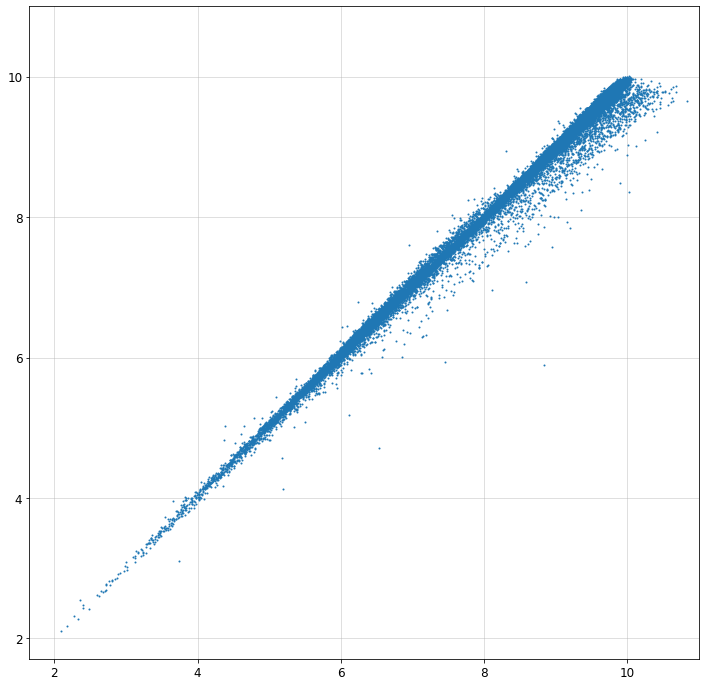

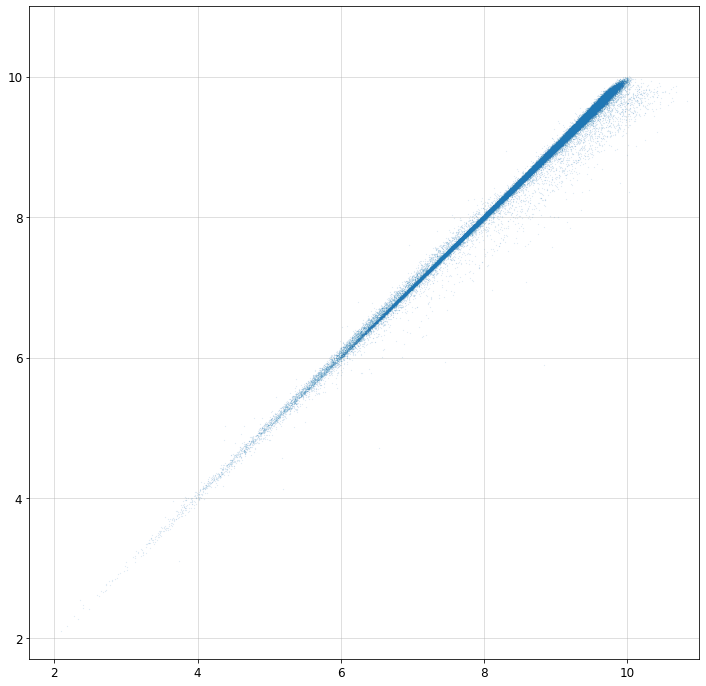

In [23]:
plt.figure(figsize=(12, 12))
plt.plot(gaia['PHOT_G_MEAN_MAG'], tycho2['ggguess'], '.', ms=2, alpha=1)
plt.xlim(xmax=11)
plt.ylim(ymax=11)
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(12, 12))
plt.plot(gaia['PHOT_G_MEAN_MAG'], tycho2['ggguess'], '.', ms=0.1, alpha=1)
plt.xlim(xmax=11)
plt.ylim(ymax=11)
plt.grid(alpha=0.5)
plt.show()

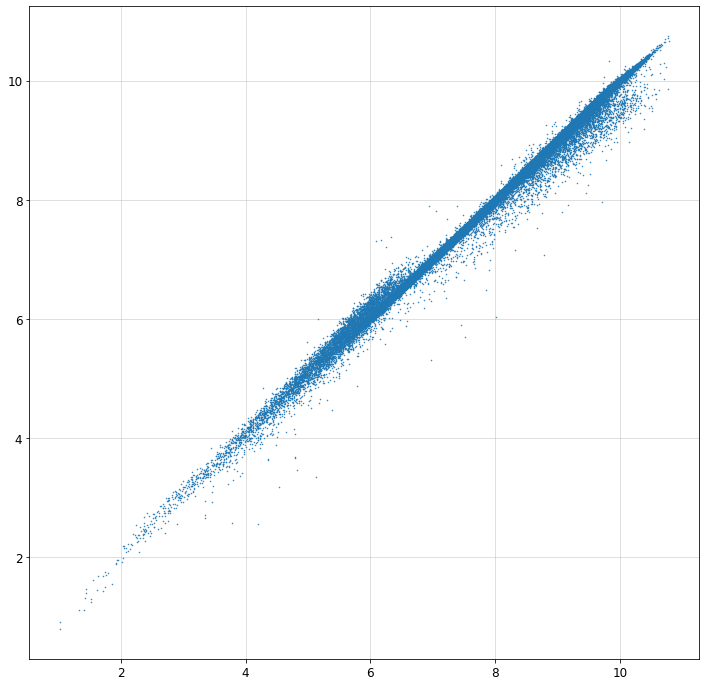

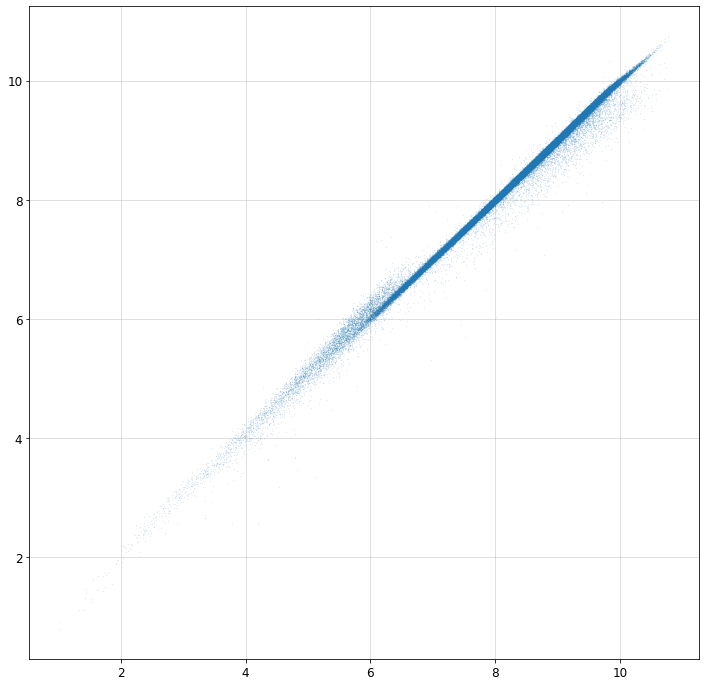

In [25]:
plt.figure(figsize=(12, 12))
plt.plot(gaia['decam_mag_z'], tycho2['zguess'], '.', ms=1, alpha=1)
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(12, 12))
plt.plot(gaia['decam_mag_z'], tycho2['zguess'], '.', ms=0.1, alpha=1)
plt.grid(alpha=0.5)
plt.show()

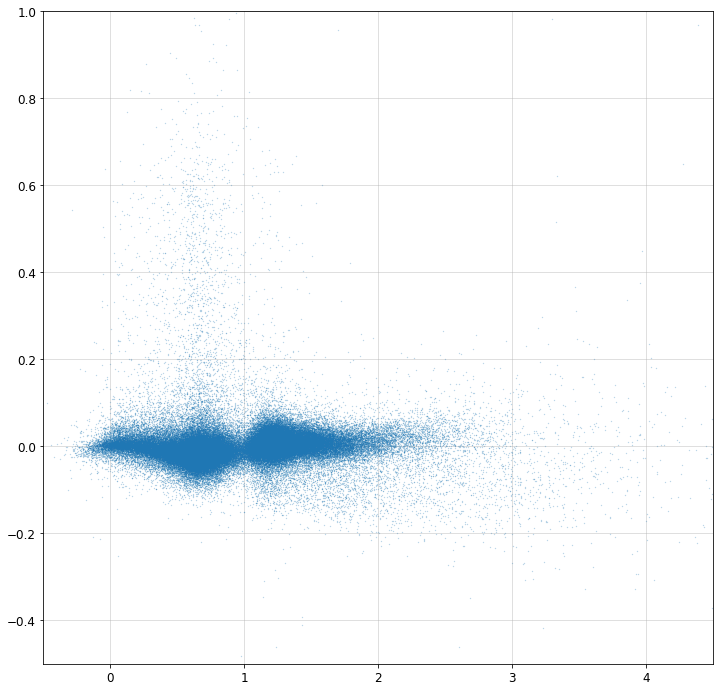

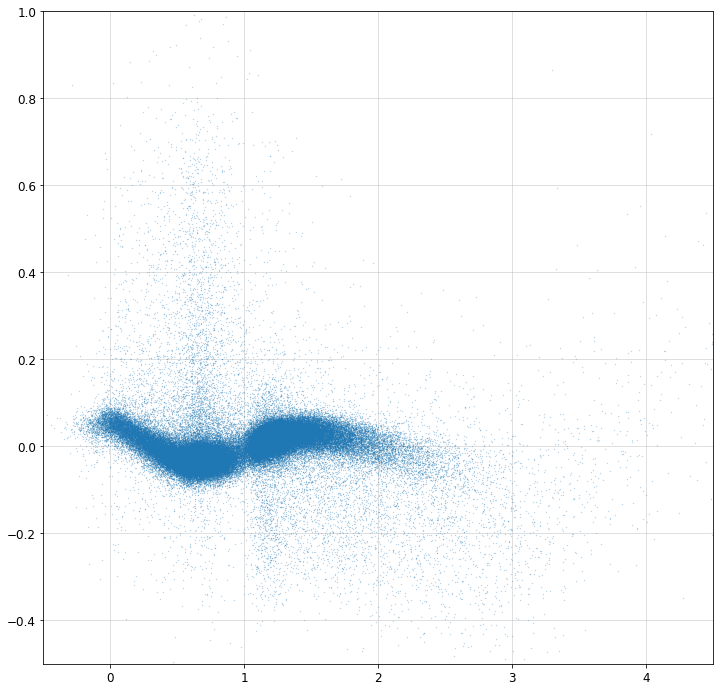

In [26]:
plt.figure(figsize=(12, 12))
plt.plot((gaia['PHOT_BP_MEAN_MAG']-gaia['PHOT_RP_MEAN_MAG']), (gaia['PHOT_G_MEAN_MAG']-tycho2['ggguess']), '.', ms=0.5, alpha=0.5)
plt.grid(alpha=0.5)
plt.axis([-0.5, 4.5, -0.5, 1.])
plt.show()

plt.figure(figsize=(12, 12))
plt.plot((gaia['PHOT_BP_MEAN_MAG']-gaia['PHOT_RP_MEAN_MAG']), (gaia['decam_mag_z']-tycho2['zguess']), '.', ms=0.5, alpha=0.5)
plt.grid(alpha=0.5)
plt.axis([-0.5, 4.5, -0.5, 1.])
plt.show()

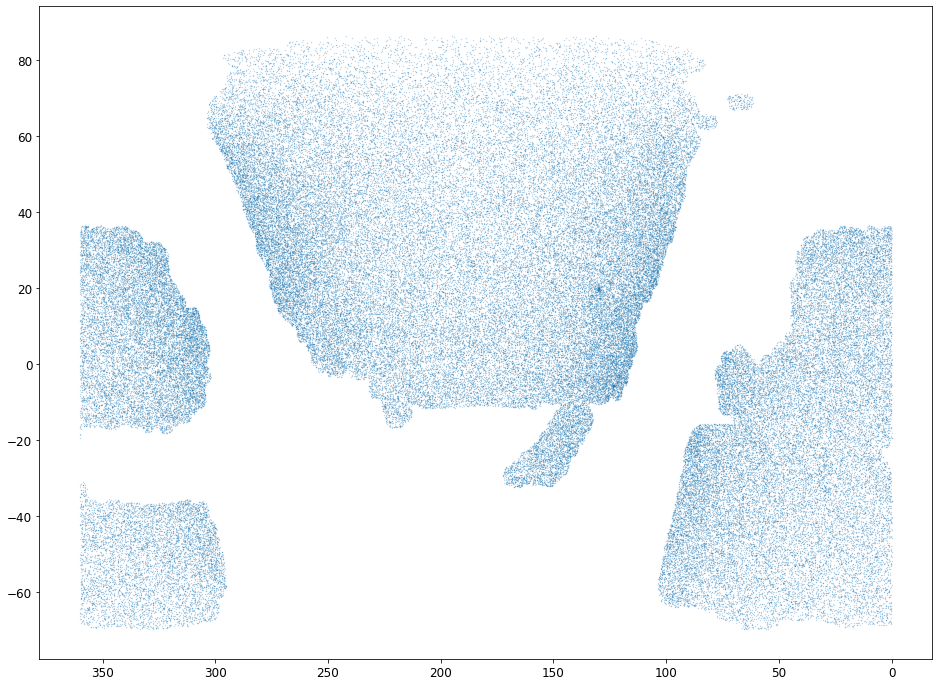

In [27]:
plt.figure(figsize=(16, 12))
plt.plot(tycho2['RA'], tycho2['DEC'], '.', ms=0.5, alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

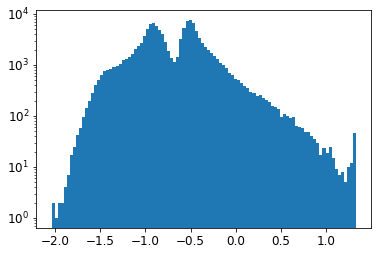

In [33]:
plt.hist((gaia['PHOT_G_MEAN_MAG']-(gaia['decam_mag_z']+1)), 100, log=True);

In [34]:
mask = gaia['PHOT_G_MEAN_MAG']-(gaia['decam_mag_z']+1)>0.
np.sum(mask), np.sum(mask)/len(mask)

(5145, 0.04128418282192836)

In [35]:
mask = gaia['PHOT_G_MEAN_MAG']-(gaia['decam_mag_z']+1)>1.
np.sum(mask), np.sum(mask)/len(mask)

(149, 0.0011955963538323277)

In [37]:
mask = gaia['PHOT_G_MEAN_MAG']-(gaia['decam_mag_z']+1)>2.
np.sum(mask), np.sum(mask)/len(mask)

(0, 0.0)

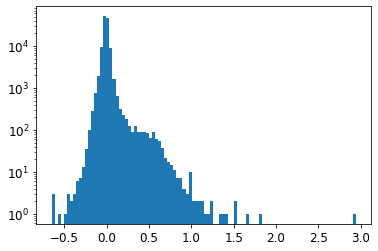

In [29]:
plt.hist((gaia['PHOT_G_MEAN_MAG']-tycho2['ggguess']), 100, log=True);

In [30]:
mask = (gaia['PHOT_G_MEAN_MAG']-tycho2['ggguess'])>0.5
np.sum(mask), np.sum(mask)/len(mask)

(423, 0.003394209783027346)

In [31]:
mask = (gaia['PHOT_G_MEAN_MAG']-tycho2['ggguess'])>1
np.sum(mask), np.sum(mask)/len(mask)

(20, 0.00016048273205803055)

In [32]:
mask = (gaia['PHOT_G_MEAN_MAG']-tycho2['ggguess'])>1.5
np.sum(mask), np.sum(mask)/len(mask)

(5, 4.012068301450764e-05)

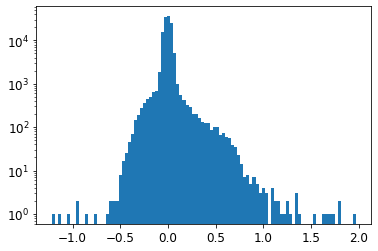

In [40]:
plt.hist((gaia['decam_mag_z']-tycho2['zguess']), 100, log=True);

In [41]:
mask = (gaia['decam_mag_z']-tycho2['zguess'])>0.5
np.sum(mask), np.sum(mask)/len(mask)

(536, 0.004300937219155219)

In [42]:
mask = (gaia['decam_mag_z']-tycho2['zguess'])>1.
np.sum(mask), np.sum(mask)/len(mask)

(29, 0.0002326999614841443)

In [43]:
mask = (gaia['decam_mag_z']-tycho2['zguess'])>2.
np.sum(mask), np.sum(mask)/len(mask)

(0, 0.0)